In [1]:
import pandas as pd
import numpy as np
from numpy import transpose as T
import glob
import os
import cartopy
import cartopy.crs as ccrs
import matplotlib
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import geopandas as gpd
from scipy.optimize import curve_fit
from netCDF4 import Dataset
import scipy
from scipy import stats
from scipy.ndimage import distance_transform_edt
from datetime import datetime,timedelta
from numpy import genfromtxt as gftxt
import regionmask
from pyproj import Transformer
from datetime import datetime,timedelta
import sys
from pathlib import Path

In [2]:
sys.path.append(str(Path.cwd().parents[0]))
from utils.grid_map_functions import(land_masking, defining_grids)

map_projection = ccrs.NorthPolarStereo()
cartopy_crs = ccrs.NorthPolarStereo(central_longitude=0)

x_grid_edge_25,y_grid_edge_25,new_x_edge_25,new_y_edge_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'edge')
x_grid_centre_25,y_grid_centre_25,new_x_centre_25,new_y_centre_25 = defining_grids(map_projection,[-180, 180, 90, 65],25000,'centre')
land_mask_25 = land_masking(new_x_centre_25,new_y_centre_25,map_projection)

transformer = Transformer.from_crs(map_projection, "EPSG:4326", always_xy=True)
lon0, lat0 = transformer.transform(new_x_centre_25.ravel(), new_y_centre_25.ravel())
lon1 = lon0.reshape(new_x_centre_25.shape)
lat1 = lat0.reshape(new_y_centre_25.shape)

from utils.stats_functions import(absdiff,corr,rmsd)

base_dir = ('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Data/')

In [3]:
def retrieving_fractions(input_folder,yrs):
    fractions = {}
    for array in input_folder:
        fraction0 = np.load(array)
        fraction = np.where(land_mask_buffered, np.nan, fraction0)
        fname = os.path.basename(array)
        date = fname.split('_')[0]
        year = str(date[0:4])
        month = str(date[4:6])
        if year in yrs:
            if year == '2018' and int(month) < 10:# don't include jan - apr for 2018
                continue
            if year == '2025' and int(month) > 4: # don't include oct - dec for 2025
                continue
            fractions[date] = fraction
    return(fractions)


def monthly_averages_allyears(fractions_dict,months):
    monthly_groups = {m: [] for m in months}
    for date, arr in fractions_dict.items():
        month = date[4:6]
        if month in monthly_groups:
            monthly_groups[month].append(arr)

    monthly_fractions = {}
    
    for month, arrays in monthly_groups.items():
        stacked = np.stack(arrays, axis=0) 
        monthly_fractions[month] = np.nanmean(stacked, axis=0)

    return(monthly_fractions)
    
def add_land_buffer_distance(land_mask, grid_spacing_km, buffer_km):
    """
    Create buffer based on real distance (km)
    """
    # दूरी from land: compute distance from NON-land
    distance = distance_transform_edt(~land_mask) * grid_spacing_km
    
    # mask where within buffer distance
    buffer_mask = distance <= buffer_km
    
    return land_mask | buffer_mask

land_mask_buffered = add_land_buffer_distance(land_mask_25,grid_spacing_km=25,buffer_km=5)


In [12]:
req_yrs = ['2018','2019','2020','2021','2022','2023','2024','2025']
winter_months = ['10','11','12','01','02','03','04']

multi_lead_folder = sorted(glob.glob(f'{base_dir}Monthly_Averages/25km/Merged/*_Lead_Density.npy'))
multi_lead_fractions = retrieving_fractions(multi_lead_folder,req_yrs)

monthly_diffs_2024,monthly_diffs_2025 = {},{}

for month in winter_months:
    if month in ['10','11','12']:
        avg_2018_2023 = np.nanmean([multi_lead_fractions[f'{year}{month:02d}']for year in range(2018, 2024) for month in [10,11,12]], 
                                   axis=0)
        avg_2024 = np.nanmean([multi_lead_fractions[f'2024{month}']], axis=0)
        monthly_diffs_2024[month] = avg_2024 - avg_2018_2023
    if month in ['01','02','03','04']:
        avg_2019_2025 = np.nanmean([multi_lead_fractions[f'{year}{month:02d}']for year in range(2019, 2025) for month in [1,2,3,4]], axis=0)
        avg_2025 = np.nanmean([multi_lead_fractions[f'2025{month}']], axis=0)
        monthly_diffs_2025[month] = avg_2025 - avg_2019_2025
        

/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_70689/4008955472.py:11: RuntimeWarning: Mean of empty slice
  avg_2018_2023 = np.nanmean([multi_lead_fractions[f'{year}{month:02d}']for year in range(2018, 2024) for month in [10,11,12]],
/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_70689/4008955472.py:13: RuntimeWarning: Mean of empty slice
  avg_2024 = np.nanmean([multi_lead_fractions[f'2024{month}']], axis=0)
/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_70689/4008955472.py:16: RuntimeWarning: Mean of empty slice
  avg_2019_2025 = np.nanmean([multi_lead_fractions[f'{year}{month:02d}']for year in range(2019, 2025) for month in [1,2,3,4]], axis=0)
/var/folders/q1/prwbhm6j6x1gcchb7r0p2kyh0000gn/T/ipykernel_70689/4008955472.py:17: RuntimeWarning: Mean of empty slice
  avg_2025 = np.nanmean([multi_lead_fractions[f'2025{month}']], axis=0)


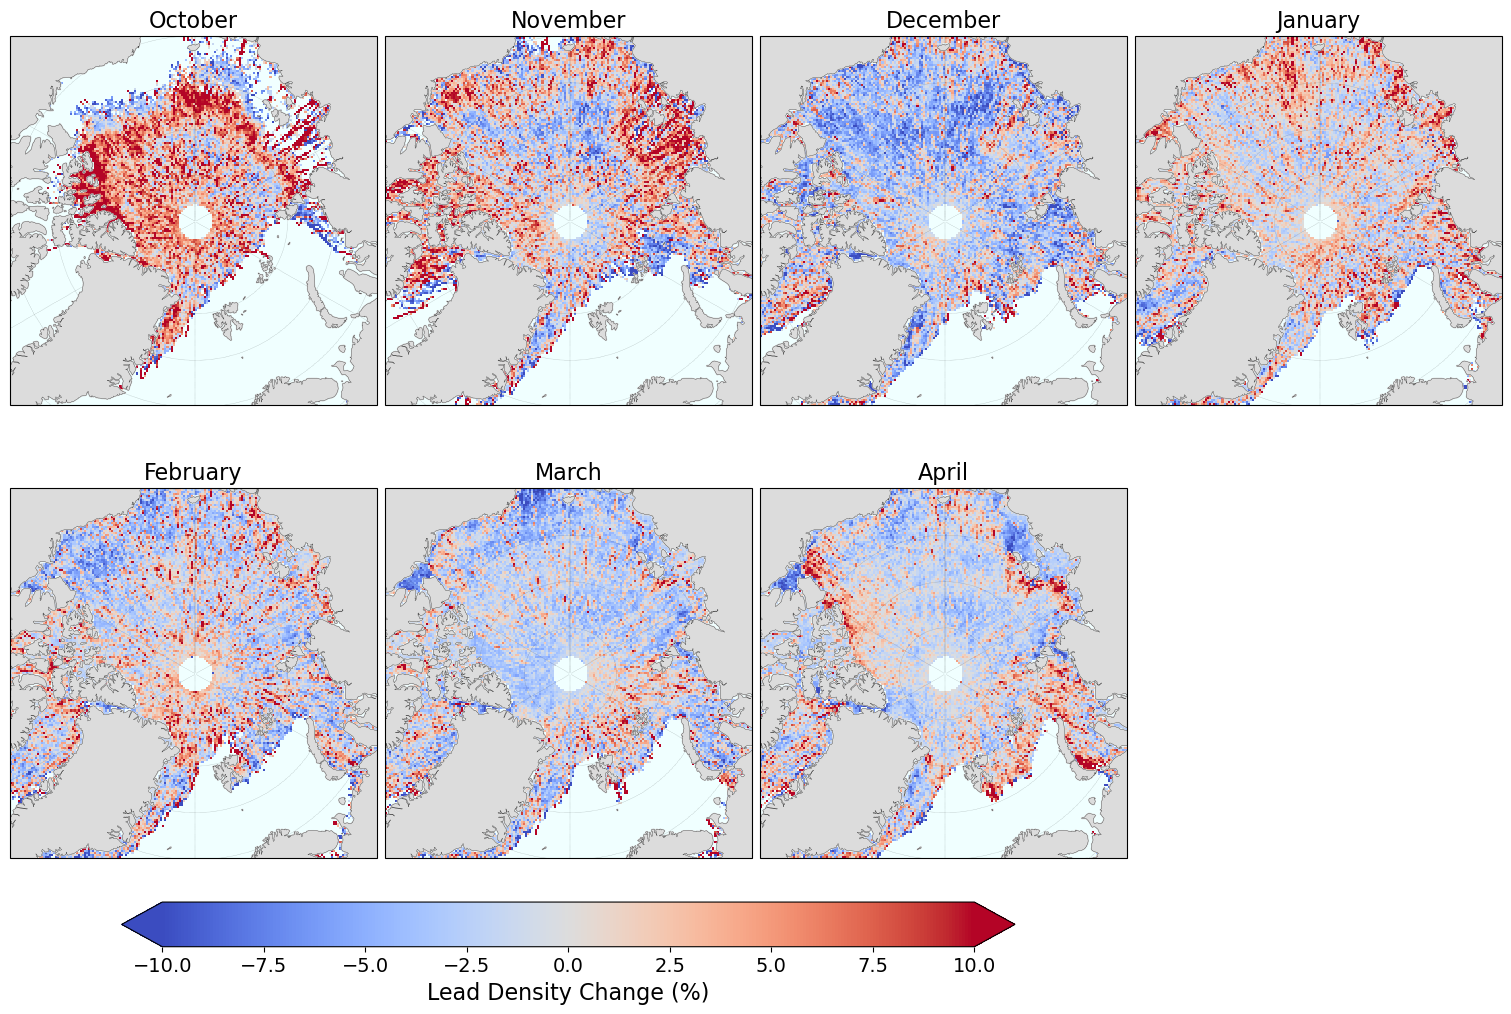

In [14]:
months_2018 = ['10','11', '12']
months_2019 = ['01', '02', '03', '04']


lead_datasets = {0: monthly_diffs_2024, 1: monthly_diffs_2025}
lead_kwargs = dict(cmap='coolwarm',transform=map_projection,vmin=-10,vmax=10,zorder=1)


fig = plt.figure(figsize=(15, 10), layout='constrained')
gs = fig.add_gridspec(2, 4)
ax = np.empty((2, 4), dtype=object)

for row in range(2):
    for col in range(4):
        ax[row, col] = fig.add_subplot(
            gs[row, col],
            projection=map_projection)

for col, month in enumerate(months_2018):
    leads = ax[0,col].pcolormesh(x_grid_centre_25,y_grid_centre_25,
        monthly_diffs_2024[month],**lead_kwargs)


for col, month in enumerate(months_2019):
    if month == '01':
        ax[0,3].pcolormesh(x_grid_centre_25,y_grid_centre_25,
                           monthly_diffs_2025[month],**lead_kwargs)
    else:
        col = col-1
        ax[1,col].pcolormesh(x_grid_centre_25,y_grid_centre_25,
                            monthly_diffs_2025[month],**lead_kwargs)

ax[1, 3].set_visible(False)

cbar = fig.colorbar(leads,ax=ax[1, 0:3] ,location = 'bottom',shrink=0.8,orientation='horizontal', extend='both', 
                    use_gridspec=True,pad=0.1)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Lead Density Change (%)', fontsize=16)

for a in ax.flatten():
    a.coastlines(linewidth=0.2,zorder=2.5)
    a.gridlines(linewidth=0.3, color='k', alpha=0.5, linestyle=':')
    a.add_feature(cartopy.feature.LAND, color=('gainsboro'), edgecolor='black',zorder=2)
    a.add_feature(cartopy.feature.OCEAN, color=('azure'),edgecolor='black',zorder=0)
    a.set_extent([-180, 180, 90, 70], ccrs.PlateCarree())

ax[0,0].set_title('October',fontsize=16)
ax[0,1].set_title('November',fontsize=16)
ax[0,2].set_title('December',fontsize=16)
ax[0,3].set_title('January',fontsize=16)
ax[1,0].set_title('February',fontsize=16)
ax[1,1].set_title('March',fontsize=16)
ax[1,2].set_title('April',fontsize=16)

plt.show()

fig.savefig('/Users/amyswiggs/Desktop/Spring_2026/Arctic_Sea_Surface_Classification/Arctic_Lead_Density_AES/Resubmission_Figures/Fig8.png',dpi=300,bbox_inches="tight")